
# 📌 Proyek: Klasifikasi Gambar Buah

Proyek ini bertujuan mengembangkan model klasifikasi gambar buah menggunakan CNN dan transfer learning.  
Model akan mengenali lima kelas buah: Apple, Banana, Grape, Mango, dan Strawberry.


## 🔧 Import Libraries

In [1]:
# 📦 Standard Library
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🧠 TensorFlow Core
import tensorflow as tf

# 📸 Image Preprocessing & Augmentation
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 🧩 Model Architecture Components
from tensorflow.keras import layers, models
from tensorflow.keras.layers import BatchNormalization, Dropout

# 🔁 Transfer Learning - MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 🧪 Model Evaluation & Callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model

# 📊 Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix

## 📥 Data Loading dan Ekstraksi Dataset

In [8]:

base_path = 'Fruits Classification'

train_dir = os.path.join(base_path, 'train')
valid_dir = os.path.join(base_path, 'valid')
test_dir = os.path.join(base_path, 'test')

train_gen = ImageDataGenerator(rescale=1./255)
valid_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(train_dir, target_size=(150,150), class_mode='categorical')
valid_data = valid_gen.flow_from_directory(valid_dir, target_size=(150,150), class_mode='categorical')
test_data = test_gen.flow_from_directory(test_dir, target_size=(150,150), class_mode='categorical', shuffle=False)


Found 9700 images belonging to 5 classes.
Found 200 images belonging to 5 classes.
Found 100 images belonging to 5 classes.


## iv. Exploratory Data Analysis (EDA)

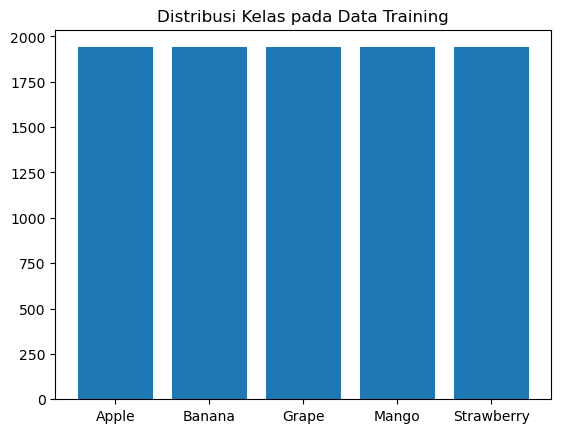

In [9]:

labels, counts = np.unique(train_data.classes, return_counts=True)
plt.bar(range(len(labels)), counts, tick_label=list(train_data.class_indices.keys()))
plt.title("Distribusi Kelas pada Data Training")
plt.show()


## v. Feature Engineering

### Augmentation with Horizontal Flip

In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=(0.7, 1.3),
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(train_dir, target_size=(224,224), class_mode='categorical')
valid_data = valid_datagen.flow_from_directory(valid_dir, target_size=(224,224), class_mode='categorical')
test_data = test_datagen.flow_from_directory(test_dir, target_size=(224,224), class_mode='categorical', shuffle=False)


Found 9700 images belonging to 5 classes.
Found 200 images belonging to 5 classes.
Found 100 images belonging to 5 classes.


## 🧠 ANN Training

### vi.1. Model Definition

In [11]:

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


### 🏋️‍♂️ Pelatihan Model

In [12]:

history = model.fit(train_data, validation_data=valid_data, epochs=10)


Epoch 1/10
304/304 [==============================] - 95s 311ms/step - loss: 1.5917 - accuracy: 0.3801 - val_loss: 1.3199 - val_accuracy: 0.3800
Epoch 2/10
304/304 [==============================] - 111s 366ms/step - loss: 1.2431 - accuracy: 0.4560 - val_loss: 1.2074 - val_accuracy: 0.4400
Epoch 3/10
304/304 [==============================] - 118s 389ms/step - loss: 1.2064 - accuracy: 0.4755 - val_loss: 1.1572 - val_accuracy: 0.4550
Epoch 4/10
304/304 [==============================] - 133s 438ms/step - loss: 1.1742 - accuracy: 0.4874 - val_loss: 1.4571 - val_accuracy: 0.2900
Epoch 5/10
304/304 [==============================] - 126s 413ms/step - loss: 1.1603 - accuracy: 0.5110 - val_loss: 1.1944 - val_accuracy: 0.4650
Epoch 6/10
304/304 [==============================] - 129s 423ms/step - loss: 1.0709 - accuracy: 0.5516 - val_loss: 1.0973 - val_accuracy: 0.5350
Epoch 7/10
304/304 [==============================] - 133s 436ms/step - loss: 1.0137 - accuracy: 0.5748 - val_loss: 1.0577 - 

### 📊 Evaluasi Model

In [13]:
loss, acc = model.evaluate(test_data)
print(f"Akurasi: {acc:.4f}")

4/4 [==============================] - 0s 90ms/step - loss: 0.9214 - accuracy: 0.6100
Akurasi: 0.6100


## 🔁 Transfer Learning

### v1. 2. Define hyperparameters

### v1. 3. Model Definition

In [14]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.3),
    layers.Dense(128, activation='relu'),
    Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

model_tl.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 🏋️‍♂️ Pelatihan Model

In [15]:

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)

history_tl = model_tl.fit(
    train_data,
    validation_data=valid_data,
    epochs=30,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/30
304/304 [==============================] - 147s 479ms/step - loss: 0.8582 - accuracy: 0.7087 - val_loss: 0.4869 - val_accuracy: 0.8250 - lr: 1.0000e-04
Epoch 2/30
304/304 [==============================] - 1390s 5s/step - loss: 0.4865 - accuracy: 0.8396 - val_loss: 0.3977 - val_accuracy: 0.8850 - lr: 1.0000e-04
Epoch 3/30
304/304 [==============================] - 95s 310ms/step - loss: 0.3844 - accuracy: 0.8663 - val_loss: 0.2641 - val_accuracy: 0.9000 - lr: 1.0000e-04
Epoch 4/30
304/304 [==============================] - 117s 385ms/step - loss: 0.3220 - accuracy: 0.8897 - val_loss: 0.2336 - val_accuracy: 0.9000 - lr: 1.0000e-04
Epoch 5/30
304/304 [==============================] - 117s 385ms/step - loss: 0.2835 - accuracy: 0.9002 - val_loss: 0.2718 - val_accuracy: 0.9150 - lr: 1.0000e-04
Epoch 6/30
304/304 [==============================] - 120s 395ms/step - loss: 0.2432 - accuracy: 0.9177 - val_loss: 0.2994 - val_accuracy: 0.8950 - lr: 1.0000e-04
Epoch 7/30
304/304 [=====

### 📊 Evaluasi Model

In [16]:

loss_tl, acc_tl = model_tl.evaluate(test_data)
print(f"Akurasi Transfer Learning: {acc_tl:.4f}")


4/4 [==============================] - 1s 196ms/step - loss: 0.1132 - accuracy: 0.9500
Akurasi Transfer Learning: 0.9500


### 📈 Evaluasi model perbandingan

In [17]:

print("Akurasi CNN Model:", acc)
print("Akurasi Transfer Learning:", acc_tl)


Akurasi CNN Model: 0.6100000143051147
Akurasi Transfer Learning: 0.949999988079071


## 💾 Model Saving

In [18]:

model_tl.save("model_transfer_learning.h5")


/opt/anaconda3/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## 🔍 Model Inference

### Load Model

In [19]:
model = load_model("model_transfer_learning.h5")


### MobileNetv2

In [20]:
# Daftar label kelas
class_labels = ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction)

    # Tampilkan gambar dan hasil
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    return predicted_class, confidence


1/1 [==============================] - 0s 332ms/step


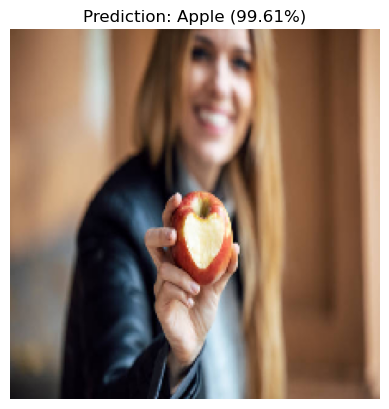

('Apple', 0.99606764)

In [21]:
# Inference with MobileNetv2...
predict_image("/Users/rizkystiawanp/Documents/#Hacktiv8/#PROJECT/Fruits_Classification/Pict_Inference/apple1.jpg")


1/1 [==============================] - 0s 27ms/step


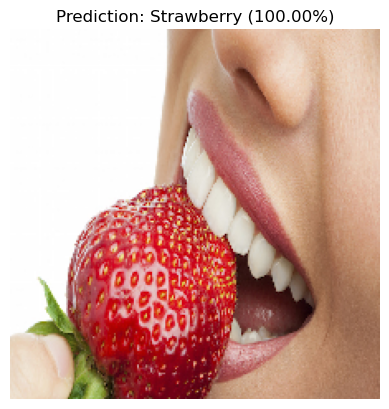

('Strawberry', 0.9999505)

In [22]:
# Inference with MobileNetv2...
predict_image("/Users/rizkystiawanp/Documents/#Hacktiv8/#PROJECT/Fruits_Classification/Pict_Inference/Eating-a-Strawberry2.jpg")


1/1 [==============================] - 0s 38ms/step


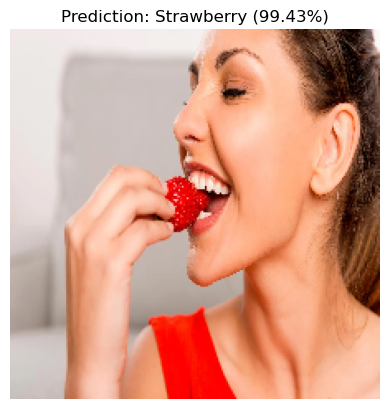

('Strawberry', 0.9943368)

In [27]:
# Inference with MobileNetv2...
predict_image("/Users/rizkystiawanp/Documents/#Hacktiv8/#PROJECT/Fruits_Classification/Pict_Inference/Eating-a-Strawberry.jpg")


1/1 [==============================] - 0s 23ms/step


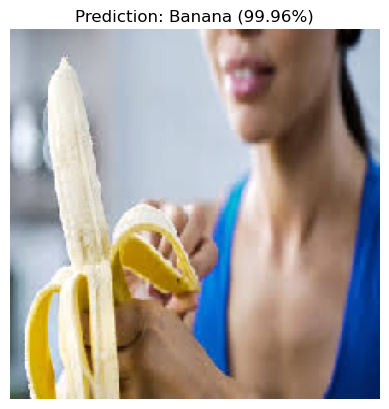

('Banana', 0.99955195)

In [23]:
# Inference with MobileNetv2...
predict_image("/Users/rizkystiawanp/Documents/#Hacktiv8/#PROJECT/Fruits_Classification/Pict_Inference/banana.jpg")


1/1 [==============================] - 0s 29ms/step


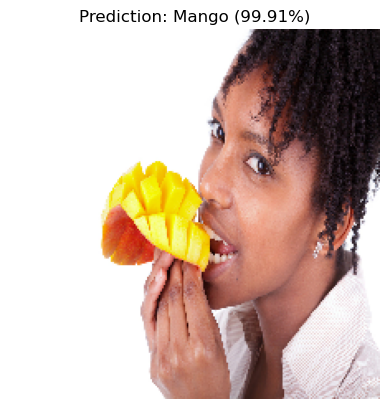

('Mango', 0.9991381)

In [24]:
# Inference with MobileNetv2...
predict_image("/Users/rizkystiawanp/Documents/#Hacktiv8/#PROJECT/Fruits_Classification/Pict_Inference/Eating-a-Mango.jpg")


1/1 [==============================] - 0s 24ms/step


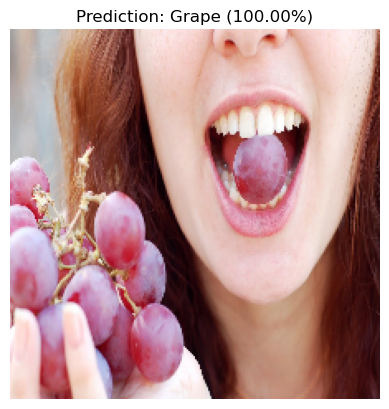

('Grape', 0.999995)

In [25]:
# Inference with MobileNetv2...
predict_image("/Users/rizkystiawanp/Documents/#Hacktiv8/#PROJECT/Fruits_Classification/Pict_Inference/grape.jpg")


## 📝 Pengambilan Kesimpulan

### ✅ Kesimpulan Proyek

Pada proyek klasifikasi gambar buah ini, kita membangun dua pendekatan model yaitu:
1. CNN sederhana yang dilatih dari awal
2. Transfer learning menggunakan **MobileNetV2**

Klasifikasi dilakukan terhadap 5 jenis buah: **Apple, Banana, Grape, Mango, dan Strawberry**.

#### 🔍 Hasil Utama:
- Teknik **augmentasi data** seperti rotasi, zoom, pergeseran, dan pencahayaan membantu meningkatkan performa model.
- Model **MobileNetV2** memberikan hasil terbaik dengan akurasi **95.00% pada data uji**.
- Fitur tambahan berupa deteksi **“Unknown / Bukan Buah”** ditambahkan agar model lebih andal terhadap input yang tidak relevan (misalnya gambar manusia atau mobil).

#### 🧠 Model Terbaik:
- MobileNetV2 dengan bobot ImageNet (transfer learning).
- Penambahan layer dense di atas dan pelatihan dengan callback **EarlyStopping** serta **ReduceLROnPlateau**.
- Model ringan dan cocok untuk di-deploy.

#### 📦 Aplikasi Siap Digunakan:
Model telah diintegrasikan ke aplikasi **Streamlit interaktif** dengan fitur:
- Upload gambar
- Input URL gambar
- Pengambilan gambar dari kamera
- Riwayat prediksi & deteksi "unknown"

#### 💡 Saran Pengembangan Selanjutnya:
- Tambahkan kelas eksplisit **“Unknown”** saat training dengan gambar selain buah (mobil, wajah, dll).
- Integrasi model deteksi objek (YOLO, SSD) untuk menangani gambar kompleks.
- Deploy model ke cloud (misalnya **Hugging Face Spaces** atau **Docker container**).

---

Proyek ini membuktikan bahwa **transfer learning** sangat efektif untuk tugas computer vision dengan data terbatas dan dapat diimplementasikan ke aplikasi nyata dengan performa yang andal.